# Decision Trees, Bagging & Random Forests — From Scratch
## DA5400W — Foundations of Machine Learning

This notebook is the **coding companion** to the DA5400W tutorial sheet.
The table below maps the 5-step CART algorithm from the slides to notebook sections,
and shows which tutorial questions each section supports.

| Step | Content | Notebook section | Tutorial question |
|------|---------|------------------|-------------------|
| 1 | List splits & compute Gini / Entropy gain | §1 — Impurity measures | Q1 (a–c) |
| 2 | Split on highest-gain condition (recursive) | §2 — DT from scratch | Q1 (d), Q2 |
| 3 | Further recursive splits | §2 continued | Q2 |
| 4 | Stopping criteria | §4 — Stopping criteria | Q3 |
| 5 | Ensemble alternatives to pruning | §5–6 — Bagging & RF | Q4, Q5 |

**Algorithm used throughout:** CART — binary splits, Gini impurity (default), same as `sklearn`.

> **Gini vs Entropy:** both measure impurity; Gini has no log so it is faster.
> §3 shows empirically that they produce near-identical accuracy on this dataset.
> Use Gini by default.

**Dataset:** 300 samples, 20 features — 4 informative + 10 redundant + 6 pure noise.
This structure is what makes DT vs Bagging vs RF differences large and clear.

---
## §0 — Setup & Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

CORAL = '#D85A30'
TEAL  = '#1D9E75'
NAVY  = '#1a2a4a'
AMBER = '#BA7517'
SAND  = '#F5E6C8'

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
print('Setup complete.')

Setup complete.


In [2]:
# ── Loan Default dataset (10 samples) — hand-calculation exercises Q1 & Q2 ──
X_loan = np.array([
    [35,2,1],[45,0,0],[28,1,0],[52,0,0],[38,2,1],
    [41,1,1],[29,0,0],[55,1,0],[33,2,1],[47,0,0]
])
y_loan = np.array([0,1,0,1,0,0,1,1,0,1]) # 5 of each class
LOAN_FEATURES = ['Age','Credit Score','Home Owner']

# ── Synthetic Credit Default dataset — used for code experiments (Q3–Q5) ──
# 300 samples, 20 features: 4 informative + 10 redundant + 6 pure noise
# F01-F04  : informative  — genuinely predict default
# F05-F14  : redundant    — correlated with informative, but add noise
# F15-F20  : pure noise   — random, zero predictive value
X_raw, y_raw = make_classification(
    n_samples=300, n_features=20, n_informative=4, n_redundant=10,
    flip_y=0.05, class_sep=0.65, random_state=7
)
FEAT_NAMES    = [f'F{i+1:02d}' for i in range(20)]
FEATURE_TYPES = ['informative']*4 + ['redundant']*10 + ['noise']*6

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.30, random_state=42)
print(f'Train: {X_tr.shape}   Test: {X_te.shape}')
print(f'm = sqrt(20) = {int(np.sqrt(20))} features sampled per RF split')

Train: (210, 20)   Test: (90, 20)
m = sqrt(20) = 4 features sampled per RF split


---
## §1 — Step 1: Impurity Measures — Gini & Entropy

Before we can split, we need to measure how *impure* a set of labels is.

$$\text{Gini}(t) = 1 - \sum_k p_k^2 \qquad \text{Entropy}(t) = -\sum_k p_k \log_2 p_k$$

Both equal **0** at a pure node and peak at **p = 0.5** (perfectly mixed).
Entropy changes more steeply near pure nodes — it is more sensitive to small impurity changes.
Gini involves no logarithm so it is faster to compute.
Section §3 shows that in practice the two criteria give nearly identical splits.

In [3]:
def gini(y):
    """Gini impurity: 1 - sum(p_k^2). Returns 0 for pure node, 0.5 for 50/50 binary."""
    if len(y) == 0: return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1.0 - np.sum(p**2)

def entropy(y):
    """Entropy: -sum(p_k * log2(p_k)). Returns 0 for pure node, 1.0 for 50/50 binary."""
    if len(y) == 0: return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum(p * np.log2(p))

# Verify against Q1 hand-calculation
print('Gini of root (5 Default, 5 No Default) :', gini(y_loan))           # expect 0.500
print('Gini of pure Left child (all Default)  :', gini(np.ones(4,int)))   # expect 0.000
print('Gini of Right child (1 Yes, 5 No)      :', gini(np.array([1,0,0,0,0,0])))  # expect 0.278
print()
print('Entropy of root (5 Default, 5 No Default):', round(entropy(y_loan),3))  # expect 1.000
print('Entropy of pure child                     :', entropy(np.ones(4,int)))  # expect 0.000

Gini of root (5 Default, 5 No Default) : 0.5
Gini of pure Left child (all Default)  : 0.0
Gini of Right child (1 Yes, 5 No)      : 0.2777777777777777

Entropy of root (5 Default, 5 No Default): 1.0
Entropy of pure child                     : -0.0


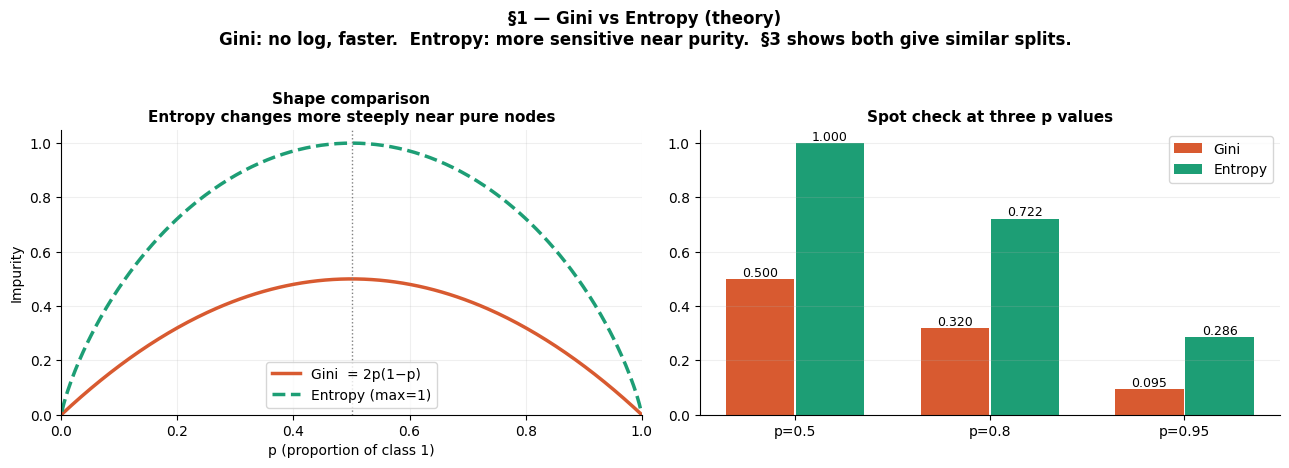

In [34]:
# ── Visualisation: Gini vs Entropy curves + spot check ────────────────────
p_vals = np.linspace(0.001, 0.999, 300)
gini_vals    = 2 * p_vals * (1 - p_vals)
entropy_vals = -(p_vals*np.log2(p_vals) + (1-p_vals)*np.log2(1-p_vals))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(p_vals, gini_vals,    color=CORAL, lw=2.5, label='Gini  = 2p(1−p)')
axes[0].plot(p_vals, entropy_vals, color=TEAL,  lw=2.5, ls='--', label='Entropy (max=1)')
axes[0].axvline(0.5, color='gray', lw=1, ls=':')
axes[0].set(xlabel='p (proportion of class 1)', ylabel='Impurity', xlim=(0,1), ylim=(0,1.05))
axes[0].set_title('Shape comparison\nEntropy changes more steeply near pure nodes',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.2)

ps_chk = [0.5, 0.8, 0.95]
g_chk  = [2*p*(1-p)                          for p in ps_chk]
e_chk  = [-(p*np.log2(p)+(1-p)*np.log2(1-p)) for p in ps_chk]
x2 = np.arange(3)
axes[1].bar(x2-0.18, g_chk, 0.35, color=CORAL, label='Gini')
axes[1].bar(x2+0.18, e_chk, 0.35, color=TEAL,  label='Entropy')
for xi,gv,ev in zip(x2, g_chk, e_chk):
    axes[1].text(xi-0.18, gv+0.01, f'{gv:.3f}', ha='center', fontsize=9)
    axes[1].text(xi+0.18, ev+0.01, f'{ev:.3f}', ha='center', fontsize=9)
axes[1].set_xticks(x2); axes[1].set_xticklabels([f'p={p}' for p in ps_chk], fontsize=10)
axes[1].set_title('Spot check at three p values',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('§1 — Gini vs Entropy (theory)\n'
             'Gini: no log, faster.  Entropy: more sensitive near purity.  §3 shows both give similar splits.',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()
# Q: At p=0.95, Gini=0.095 and Entropy=0.286. Why does this matter when choosing a stopping criterion?

---
## §2 — Steps 1, 2 & 3: Building a Decision Tree from Scratch

**Step 1:** For every feature and every threshold, compute the impurity gain.

**Step 2:** Split on the feature+threshold with maximum gain.

**Step 3:** Recurse on each child — repeat steps 1 & 2 until stopping.

$$\text{Gain} = \text{Impurity(parent)} - \left[\frac{N_L}{N}\text{Imp}(L) + \frac{N_R}{N}\text{Imp}(R)\right]$$

`build_tree` accepts `criterion='gini'` (default) or `criterion='entropy'`.
This single parameter is all that changes between the two criteria — no code duplication needed.

In [5]:
# ── Node data structure ────────────────────────────────────────────────────
@dataclass
class Node:
    feature:   Optional[int]    = None   # which feature to split on
    threshold: Optional[float]  = None   # go left if x[feature] <= threshold
    left:      Optional['Node'] = None
    right:     Optional['Node'] = None
    value:     Optional[float]  = None   # set ONLY at leaf (class for clf, mean for reg)
    gini_gain: float            = 0.0   # impurity gain at this split
    n_samples: int              = 0
    def is_leaf(self): return self.value is not None

In [6]:
# ── Step 1: Find best split at a node ──────────────────────────────────────
# Accepts an impurity_fn so the same function works for both Gini and Entropy
# (and variance for regression in §10).
def best_split(X, y, feature_subset=None, impurity_fn=gini):
    best_gain, best_feat, best_thresh = -1, None, None
    parent_imp = impurity_fn(y)
    n = len(y)
    feats = feature_subset if feature_subset is not None else range(X.shape[1])
    for feat in feats:
        for thresh in np.unique(X[:, feat]):
            left  = y[X[:, feat] <= thresh]
            right = y[X[:, feat] >  thresh]
            if len(left) == 0 or len(right) == 0: continue
            gain = parent_imp - (len(left)/n)*impurity_fn(left) - (len(right)/n)*impurity_fn(right)
            if gain > best_gain:
                best_gain, best_feat, best_thresh = gain, feat, thresh
    return best_feat, best_thresh, best_gain

# Verify on Q1: best split should be Credit Score <= 0 with gain ≈ 0.333
feat, thresh, gain = best_split(X_loan, y_loan)
print(f'Best split: {LOAN_FEATURES[feat]} <= {thresh}')
print(f'Gini Gain : {gain:.3f}')

Best split: Age <= 41
Gini Gain : 0.333


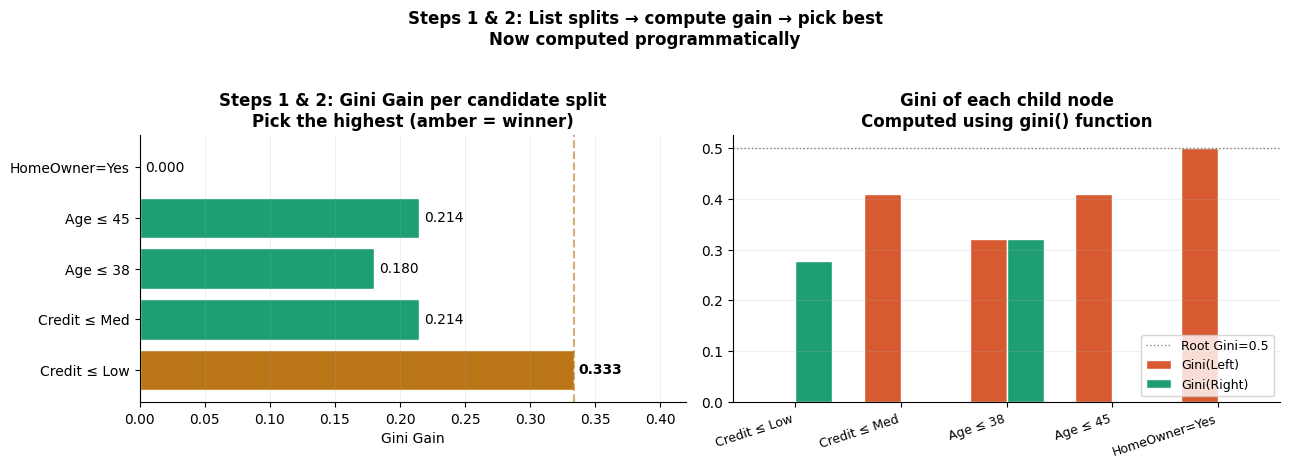

In [7]:
# ── Visualise Gini gain for all Q1 candidate splits (computed, not hardcoded) ──

# Define splits as (label, feature_index, threshold)
candidate_splits = [
    ('Credit ≤ Low',  1, 0),   # Credit Score ≤ 0
    ('Credit ≤ Med',  1, 1),   # Credit Score ≤ 1
    ('Age ≤ 38',      0, 38),
    ('Age ≤ 45',      0, 45),
    ('HomeOwner=Yes', 2, 1),
]

labels, gains, gL, gR = [], [], [], []

parent_imp = gini(y_loan)
n = len(y_loan)

for name, feat, thresh in candidate_splits:
    left  = y_loan[X_loan[:, feat] <= thresh]
    right = y_loan[X_loan[:, feat] >  thresh]

    g_left  = gini(left)
    g_right = gini(right)

    gain = parent_imp - (len(left)/n)*g_left - (len(right)/n)*g_right

    labels.append(name)
    gains.append(gain)
    gL.append(g_left)
    gR.append(g_right)

# ── Plotting ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = [AMBER if g == max(gains) else TEAL for g in gains]
bars = axes[0].barh(labels, gains, color=colors, edgecolor='white')

axes[0].axvline(max(gains), color=AMBER, lw=1.5, ls='--', alpha=0.6)

for bar, g in zip(bars, gains):
    axes[0].text(g+0.004, bar.get_y()+bar.get_height()/2, f'{g:.3f}',
                 va='center', fontsize=10,
                 fontweight='bold' if g == max(gains) else 'normal')

axes[0].set_xlabel('Gini Gain')
axes[0].set_xlim(0, 0.42)
axes[0].set_title('Steps 1 & 2: Gini Gain per candidate split\nPick the highest (amber = winner)',
                  fontweight='bold')
axes[0].grid(axis='x', alpha=0.2)

x = np.arange(len(candidate_splits)); w = 0.35
axes[1].bar(x-w/2, gL, w, color=CORAL, label='Gini(Left)',  edgecolor='white')
axes[1].bar(x+w/2, gR, w, color=TEAL,  label='Gini(Right)', edgecolor='white')

axes[1].axhline(0.5, color='gray', lw=1, ls=':', label='Root Gini=0.5')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=18, ha='right', fontsize=9)

axes[1].set_title('Gini of each child node\nComputed using gini() function',
                  fontweight='bold')

axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('Steps 1 & 2: List splits → compute gain → pick best\nNow computed programmatically',
             fontsize=12, fontweight='bold', y=1.03)

plt.tight_layout()
plt.show()

In [8]:
# ── Steps 2 & 3: Recursive CART builder ───────────────────────────────────
def build_tree(X, y, max_depth=None, min_samples=2, min_gain=0.0,
               depth=0, max_features=None, criterion='gini'):
    """CART classification tree.

    Stopping conditions (any one → leaf node):
      - depth >= max_depth
      - fewer than min_samples samples at this node
      - all samples belong to one class (pure)
      - best split gain < min_gain

    criterion : 'gini' (default) or 'entropy' — selects the impurity function.
    max_features : if set, randomly sample only this many features per split (RF mode).
    """
    impurity_fn = gini if criterion == 'gini' else entropy
    n = len(y)
    md = max_depth if max_depth is not None else 99999

    # ── Step 4 stopping conditions ──────────────────────────────────────────
    if depth >= md or n < min_samples or len(np.unique(y)) == 1: ## return condition 1
        return Node(value=float(np.bincount(y).argmax()), n_samples=n)  ## finds majority class and assigns that value to the node

    # ── RF: randomly restrict feature search ────────────────────────────────
    fs = None
    if max_features:
        fs = np.random.choice(X.shape[1], max_features, replace=False) ## random subset of features

    feat, thresh, gain = best_split(X, y, fs, impurity_fn) ### calculating best split feature, threshold
    if feat is None or gain < min_gain:    ## return condition 2
        return Node(value=float(np.bincount(y).argmax()), n_samples=n)

    # ── Step 2: split and recurse (Step 3) ─────────────────────────────────
    mask = X[:, feat] <= thresh
    return Node(
        feature=feat, threshold=thresh, gini_gain=gain, n_samples=n,
        left  = build_tree(X[mask],  y[mask],  max_depth, min_samples, min_gain,
                           depth+1, max_features, criterion),
        right = build_tree(X[~mask], y[~mask], max_depth, min_samples, min_gain,
                           depth+1, max_features, criterion),
    )

def predict_one(node, x):
    if node.is_leaf(): return node.value
    return predict_one(node.left, x) if x[node.feature] <= node.threshold else predict_one(node.right, x)

def predict(tree, X):   ## following the path until we reach the particular combination node of all features
    return np.array([predict_one(tree, x) for x in X])

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [35]:

def print_tree(node, feat_names=None, depth=0, prefix='Root'):
    indent = '  ' * depth
    if node.is_leaf():
        label = 'Default' if node.value >= 0.5 else 'No Default'
        print(f'{indent}{prefix} → Predict: {label}  [{node.n_samples} samples]')
        return
    fname = feat_names[node.feature] if feat_names else f'F{node.feature}'
    print(f'{indent}{prefix}: {fname} ≤ {node.threshold:.3g}  '
          f'[gain={node.gini_gain:.3f}, n={node.n_samples}]')
    print_tree(node.left,  feat_names, depth+1, 'LEFT  (yes)')
    print_tree(node.right, feat_names, depth+1, 'RIGHT (no)')

np.random.seed(42)
tree_loan = build_tree(X_loan, y_loan, max_depth=3, min_samples=1) ## building tree for loan data
print('=== Tree learned from Loan dataset (Q1 / Q2) ===')
print_tree(tree_loan, LOAN_FEATURES)

=== Tree learned from Loan dataset (Q1 / Q2) ===
Root: Age ≤ 41  [gain=0.333, n=10]
  LEFT  (yes): Credit Score ≤ 0  [gain=0.278, n=6]
    LEFT  (yes) → Predict: Default  [1 samples]
    RIGHT (no) → Predict: No Default  [5 samples]
  RIGHT (no) → Predict: Default  [4 samples]


In [36]:
from graphviz import Digraph

def visualize_tree(node, feat_names=None):
    dot = Digraph()

    def add_nodes_edges(node, parent=None, edge_label=''):
        node_id = str(id(node))

        # Leaf node
        if node.is_leaf():
            label = 'Default' if node.value >= 0.5 else 'No Default'
            dot.node(node_id, f'{label}\nSamples={node.n_samples}', shape='box')
        else:
            fname = feat_names[node.feature] if feat_names else f'F{node.feature}'
            dot.node(node_id,
                     f'{fname} ≤ {node.threshold:.2f}\nGain={node.gini_gain:.3f}\nSamples={node.n_samples}')

        if parent:
            dot.edge(parent, node_id, label=edge_label)

        if not node.is_leaf():
            add_nodes_edges(node.left, node_id, 'Yes')
            add_nodes_edges(node.right, node_id, 'No')

    add_nodes_edges(node)
    return dot

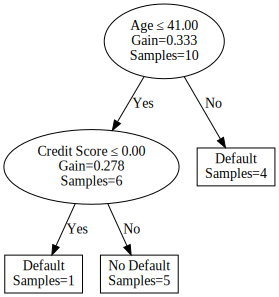

In [37]:
dot = visualize_tree(tree_loan, LOAN_FEATURES)
dot

In [38]:
# Classify Q2 query: Age=40, Credit=Low(0), HomeOwner=No(0)
query = np.array([[40, 0, 0]])
pred  = predict(tree_loan, query)[0] #3 prediction for a particular split on the built tree
print(f'Query (Age=40, Credit=Low, HomeOwner=No) → Predict: {"Default" if pred >= 0.5 else "No Default"}')

Query (Age=40, Credit=Low, HomeOwner=No) → Predict: Default


In [10]:
# ── DT on credit dataset: unlimited depth shows overfitting ────────────────
np.random.seed(42)
dt = build_tree(X_tr, y_tr)   # no max_depth = grows until every leaf is pure

dt_train = accuracy(y_tr, predict(dt, X_tr))
dt_test  = accuracy(y_te, predict(dt, X_te))
print(f'Decision Tree (unlimited depth, 20 features)')
print(f'  Train: {dt_train:.3f}   ← memorises ALL training data')
print(f'  Test : {dt_test:.3f}   ← collapses on unseen data')
print(f'  Gap  : {dt_train - dt_test:.3f}   ← large gap!')
print()
print('Why? The 16 non-informative features are freely used as split candidates.')
print('With unlimited depth the tree finds splits on noise that fit training perfectly.')
print('Those noise splits generalise to nothing on test data.')

Decision Tree (unlimited depth, 20 features)
  Train: 1.000   ← memorises ALL training data
  Test : 0.678   ← collapses on unseen data
  Gap  : 0.322   ← large gap!

Why? The 16 non-informative features are freely used as split candidates.
With unlimited depth the tree finds splits on noise that fit training perfectly.
Those noise splits generalise to nothing on test data.


---
## §3 — Gini vs Entropy: Empirical Comparison on Credit Dataset

§1 showed the curves differ in shape near pure nodes.
Here we check whether that difference actually changes which splits are chosen,
and whether it affects test accuracy.

`build_tree(... criterion='entropy')` is all we need — no code duplication.

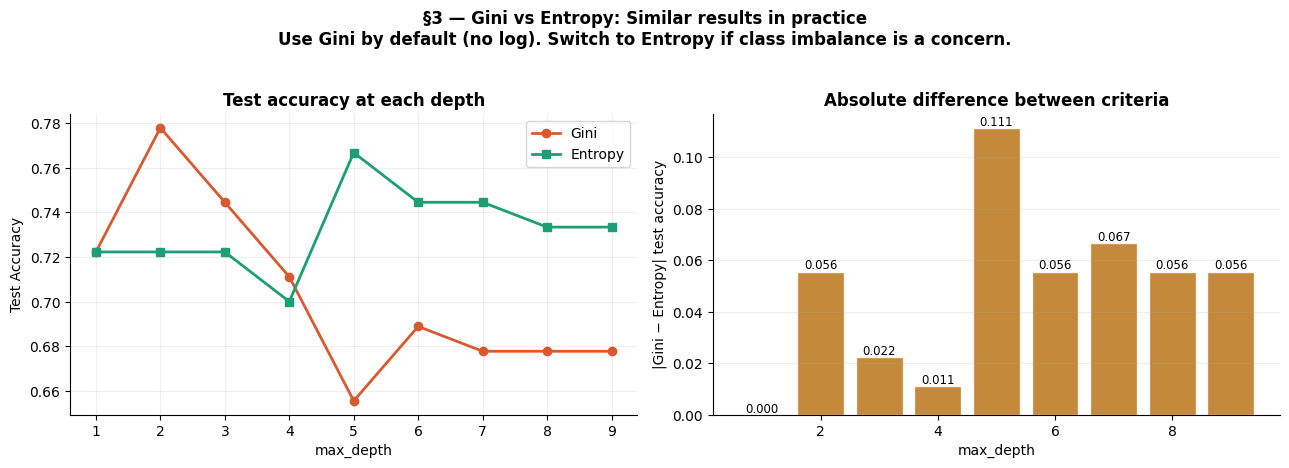

In [11]:
# ── Does criterion choice change test accuracy? ──────────────────────────── ## 30 seconds
np.random.seed(42)
depths_c = list(range(1, 10))
gini_te, entr_te = [], []
for d in depths_c:
    tg = build_tree(X_tr, y_tr, max_depth=d, criterion='gini')
    te_e = build_tree(X_tr, y_tr, max_depth=d, criterion='entropy')
    gini_te.append(accuracy(y_te, predict(tg, X_te)))
    entr_te.append(accuracy(y_te, predict(te_e, X_te)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(depths_c, gini_te, 'o-', color=CORAL, lw=2, label='Gini')
axes[0].plot(depths_c, entr_te, 's-', color=TEAL,  lw=2, label='Entropy')
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test accuracy at each depth', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.2)

diffs = [abs(g-e) for g,e in zip(gini_te, entr_te)]
axes[1].bar(depths_c, diffs, color=AMBER, edgecolor='white', alpha=0.85)
for x, d in zip(depths_c, diffs):
    axes[1].text(x, d+0.001, f'{d:.3f}', ha='center', fontsize=8.5)
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('|Gini − Entropy| test accuracy')
axes[1].set_title('Absolute difference between criteria', fontweight='bold')
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('§3 — Gini vs Entropy: Similar results in practice\n'
             'Use Gini by default (no log). Switch to Entropy if class imbalance is a concern.',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## §4 — Step 4: Stopping Criteria(Pruning)

The unlimited tree above perfectly memorised training data. Stopping criteria prevent this:

| Criterion | Parameter | Effect |
|-----------|-----------|--------|
| Max depth | `max_depth` | Hard limit on tree layers |
| Min samples per leaf | `min_samples` | Requires a minimum number of samples before splitting |
| Min impurity decrease | `min_gain` | Only split if gain exceeds a threshold |

In practice, **all three are used together**. Pruning achieves the same goal post-hoc
(build the full tree, then remove leaves that hurt validation accuracy).

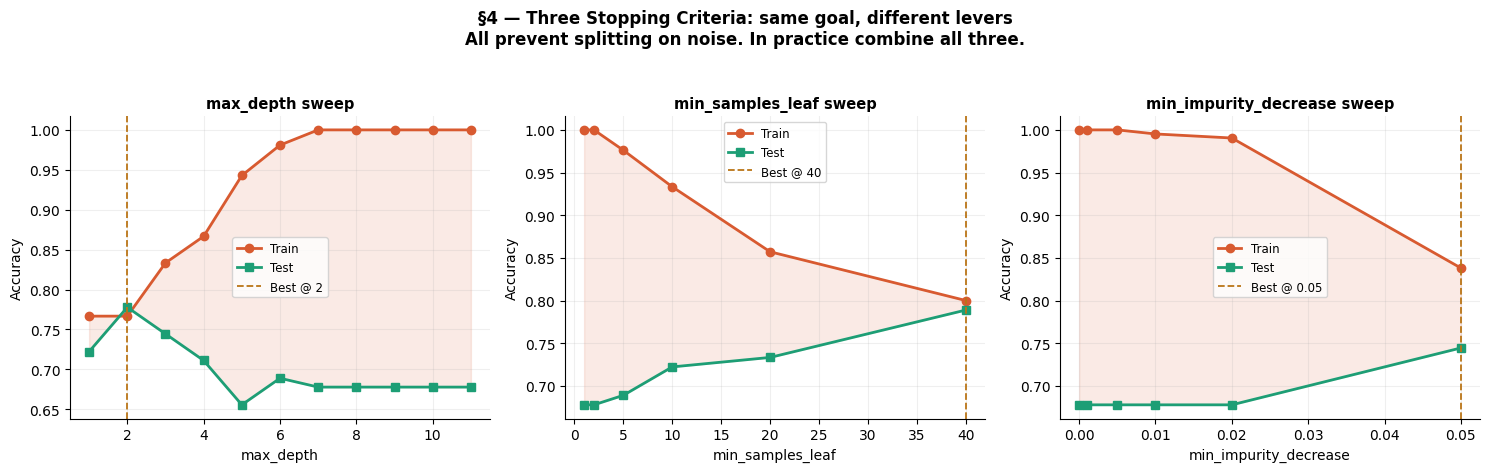

Best max_depth   = 2
Best min_samples = 40


In [12]:
# ── Stopping criterion sweep: three panels ───────────────────────────────── #20 seconds
np.random.seed(42)

# 1. max_depth sweep
depths = list(range(1, 12))
dtr, dte = [], []
for d in depths:
    t = build_tree(X_tr, y_tr, max_depth=d)
    dtr.append(accuracy(y_tr, predict(t, X_tr)))
    dte.append(accuracy(y_te, predict(t, X_te)))

# 2. min_samples_leaf sweep
leaf_sizes = [1, 2, 5, 10, 20, 40]
ltr, lte = [], []
for ls in leaf_sizes:
    t = build_tree(X_tr, y_tr, min_samples=ls)
    ltr.append(accuracy(y_tr, predict(t, X_tr)))
    lte.append(accuracy(y_te, predict(t, X_te)))

# 3. min_gain sweep
min_gains = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
gtr, gte = [], []
for mg in min_gains:
    t = build_tree(X_tr, y_tr, min_gain=mg)
    gtr.append(accuracy(y_tr, predict(t, X_tr)))
    gte.append(accuracy(y_te, predict(t, X_te)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, xs, tr, te, xl, ttl in [
    (axes[0], depths,     dtr, dte, 'max_depth',            'max_depth sweep'),
    (axes[1], leaf_sizes, ltr, lte, 'min_samples_leaf',     'min_samples_leaf sweep'),
    (axes[2], min_gains,  gtr, gte, 'min_impurity_decrease','min_impurity_decrease sweep')]:
    ax.plot(xs, tr, 'o-', color=CORAL, lw=2, label='Train')
    ax.plot(xs, te, 's-', color=TEAL,  lw=2, label='Test')
    ax.fill_between(xs, tr, te, alpha=0.12, color=CORAL)
    best = xs[int(np.argmax(te))]
    ax.axvline(best, color=AMBER, lw=1.3, ls='--', label=f'Best @ {best}')
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_title(ttl, fontsize=10.5, fontweight='bold')
    ax.legend(fontsize=8.5); ax.grid(alpha=0.2)
plt.suptitle('§4 — Three Stopping Criteria: same goal, different levers\n'
             'All prevent splitting on noise. In practice combine all three.',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()
print(f'Best max_depth   = {depths[np.argmax(dte)]}')
print(f'Best min_samples = {leaf_sizes[np.argmax(lte)]}')

---
## §5 — Bagging from Scratch (Q4)

A single deep tree has **high variance**: small changes in training data → completely different tree.

**Bootstrap Aggregation (Bagging):** Train B trees, each on a different bootstrap sample
(draw N samples *with replacement* → ~37% of points unused in each sample).
Predict by **majority vote**.

Each tree overfits differently → errors cancel out in the vote.

> **Key property:** Bagging reduces variance without increasing bias.
> $$\text{Var}(\hat{f}_{\text{bag}}) = \rho\sigma^2 + \frac{(1-\rho)\sigma^2}{B}$$
> where ρ is pairwise tree correlation. More trees (larger B) shrinks the second term.

In [28]:
class BaggedForest:

    def __init__(self, n_trees=20, max_depth=None, min_samples=2):
        self.n_trees=n_trees; self.max_depth=max_depth
        self.min_samples=min_samples; self.trees=[]

    def fit(self, X, y):
        self.trees = []
        n = len(y)
        for t in range(self.n_trees):
            # Bootstrap — draw N samples WITH replacement (~37% of points are OOB)
            idx  = np.random.choice(n, n, replace=True)  ##1st n. choose from n indices ##2. choose n values
            tree = build_tree(X[idx], y[idx], self.max_depth, self.min_samples)
            self.trees.append(tree)
        return self

    def predict(self, X):
        # Collect one vote per tree, then take majority
        # votes shape: (n_trees, n_samples)
        votes = np.array([predict(tree, X) for tree in self.trees])
        # np.round before bincount because Node.value is float (majority class stored as float)
        int_votes = np.round(votes).astype(int)
        return np.array([np.bincount(int_votes[:, i]).argmax() for i in range(X.shape[0])])


np.random.seed(42)
bag = BaggedForest(n_trees=50).fit(X_tr, y_tr)

bag_train = accuracy(y_tr, bag.predict(X_tr))
bag_test  = accuracy(y_te, bag.predict(X_te))
dt_test_ref = accuracy(y_te, predict(build_tree(X_tr, y_tr), X_te))

print(f'Bagging (50 trees, unlimited depth)')
print(f'  Train: {bag_train:.3f}')
print(f'  Test : {bag_test:.3f}   ← was {dt_test_ref:.3f} for single DT')
print(f'  Gap  : {bag_train - bag_test:.3f}')
print(f'  Improvement vs single DT: +{bag_test - dt_test_ref:.3f} (+{(bag_test-dt_test_ref)*100:.1f}pp)')

Bagging (50 trees, unlimited depth)
  Train: 1.000
  Test : 0.800   ← was 0.678 for single DT
  Gap  : 0.200
  Improvement vs single DT: +0.122 (+12.2pp)


---
## §6 — Random Forest from Scratch (Q5)

**Problem with Bagging:** Even after bootstrap sampling, a strong feature tends to dominate the root
of every tree → trees become structurally similar → high correlation ρ → variance reduction is limited
(the first term ρσ² in the variance formula stays large).

**Random Forest fix:** At each split, randomly sample only **m = √p** features.
Trees are forced to find different patterns → ρ drops → variance drops further.

| | Bagging | Random Forest |
|---|---|---|
| Bootstrap | ✓ | ✓ |
| Features/split | All p | Random m = √p |
| Tree correlation ρ | Moderate | Low |
| Variance reduction | Moderate | High |

> **This is one extra argument in `build_tree`.** That's the entire RF modification.

In [29]:
class RandomForest:

    def __init__(self, n_trees=20, max_depth=None, min_samples=2, max_features=None):
        self.n_trees=n_trees; self.max_depth=max_depth
        self.min_samples=min_samples; self.max_features=max_features; self.trees=[]

    def fit(self, X, y):
        self.trees = []
        n, p = X.shape
        m = self.max_features or max(1, int(np.sqrt(p)))   # default: sqrt(p)
        print(f'  m = {m} features per split out of p = {p}')
        for t in range(self.n_trees):
            idx  = np.random.choice(n, n, replace=True)    # bootstrap (same as Bagging) ##1st n. choose from n indices ##2. choose n values
            tree = build_tree(X[idx], y[idx], self.max_depth, self.min_samples,
                              max_features=m)               # ← the only change vs Bagging
            self.trees.append(tree)
        return self

    def predict(self, X):
        votes = np.array([predict(tree, X) for tree in self.trees])
        int_votes = np.round(votes).astype(int)
        return np.array([np.bincount(int_votes[:, i]).argmax() for i in range(X.shape[0])])


np.random.seed(42)
rf = RandomForest(n_trees=50).fit(X_tr, y_tr)
print()
rf_train = accuracy(y_tr, rf.predict(X_tr))
rf_test  = accuracy(y_te, rf.predict(X_te))
print(f'Random Forest (50 trees, unlimited depth, m=√20≈4)')
print(f'  Train: {rf_train:.3f}')
print(f'  Test : {rf_test:.3f}')
print(f'  Gap  : {rf_train - rf_test:.3f}')
print(f'  vs Bagging: +{rf_test - bag_test:.3f}')

  m = 4 features per split out of p = 20

Random Forest (50 trees, unlimited depth, m=√20≈4)
  Train: 1.000
  Test : 0.844
  Gap  : 0.156
  vs Bagging: +0.044


In [15]:
# ── Verification: RF with max_features=p reduces to Bagging ─────────────── ## 40-60 sec
# The ONLY algorithmic difference between Bagging and RF is max_features.
# Setting max_features=p (all features) should give Bagging-like accuracy.
np.random.seed(42)
rf_all = RandomForest(n_trees=50, max_features=20).fit(X_tr, y_tr)
print()
print(f'RF(max_features=20, all features) test : {accuracy(y_te, rf_all.predict(X_te)):.3f}')
print(f'Bagging test                            : {bag_test:.3f}')
print()
print('Numbers are close (may differ slightly due to per-split random state,')
print('but the conceptual point holds: feature restriction is the only meaningful difference.')

  m = 20 features per split out of p = 20

RF(max_features=20, all features) test : 0.789
Bagging test                            : 0.800

Numbers are close (may differ slightly due to per-split random state,
but the conceptual point holds: feature restriction is the only meaningful difference.


---
## §7 — Validation Against sklearn

A standard sanity check: do our from-scratch numbers agree with sklearn's battle-tested implementation?
We expect small differences (different random seeds, slightly different tie-breaking) but
the test accuracies should be in the same ballpark.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

np.random.seed(42)
sk_dt  = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
sk_bag = BaggingClassifier(n_estimators=50, random_state=42).fit(X_tr, y_tr)
sk_rf  = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_tr, y_tr)

# From-scratch results (reuse objects trained in §5–§6)
fs_dt_acc  = accuracy(y_te, predict(build_tree(X_tr, y_tr), X_te))
fs_bag_acc = bag_test
fs_rf_acc  = rf_test

print(f'  {"Model":<28} {"From-scratch":>14} {"sklearn":>10}')
print('  ' + '-'*55)
print(f'  {"Decision Tree (unlimited)":<28} {fs_dt_acc:>14.3f} {sk_dt.score(X_te, y_te):>10.3f}')
print(f'  {"Bagging (50 trees)":<28} {fs_bag_acc:>14.3f} {sk_bag.score(X_te, y_te):>10.3f}')
print(f'  {"Random Forest (50 trees)":<28} {fs_rf_acc:>14.3f} {sk_rf.score(X_te, y_te):>10.3f}')
print()
print('If from-scratch and sklearn numbers are within ~3 pp on all rows, the implementation is correct.')
print('Larger gaps likely mean a bug in best_split or the bootstrapping loop — recheck those cells.')

  Model                          From-scratch    sklearn
  -------------------------------------------------------
  Decision Tree (unlimited)             0.678      0.711
  Bagging (50 trees)                    0.800      0.800
  Random Forest (50 trees)              0.844      0.811

If from-scratch and sklearn numbers are within ~3 pp on all rows, the implementation is correct.
Larger gaps likely mean a bug in best_split or the bootstrapping loop — recheck those cells.


---
## §8 — Visualisations & Analysis

### Plot A: Summary — Train vs Test for all three models

  m = 4 features per split out of p = 20
  Model                             Train     Test      Gap
  -------------------------------------------------------
  Decision Tree (unlimited depth)    1.000    0.678    0.322
  Bagging (50 trees)                1.000    0.800    0.200
  Random Forest (50 trees)          1.000    0.822    0.178


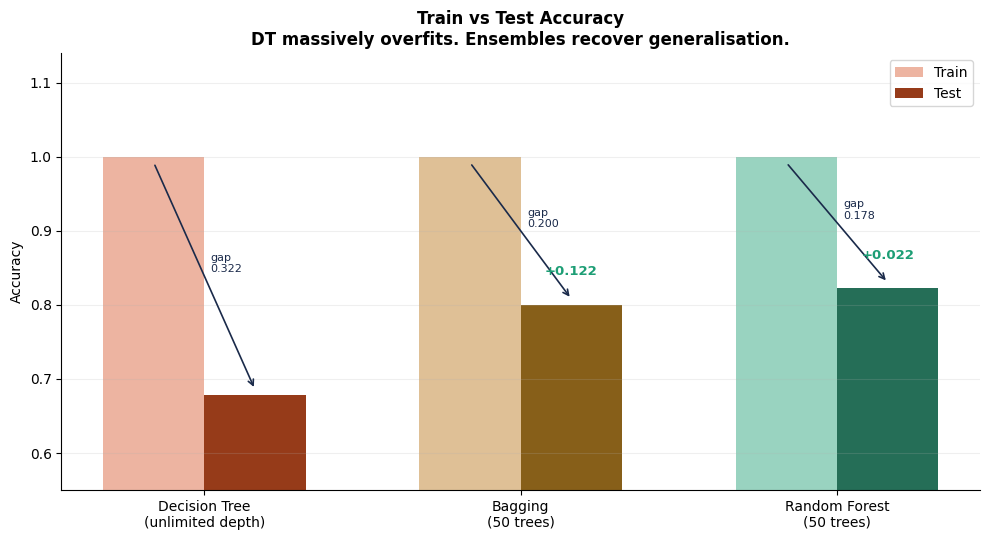

In [17]:
# Rebuild with a fixed seed for reproducibility across notebook runs.
# (Rerunning §5–§6 with a different seed would change bag_test / rf_test;
#  this cell pins the comparison to seed=42.)
np.random.seed(42)
dt_f  = build_tree(X_tr, y_tr)
bag_f = BaggedForest(n_trees=50).fit(X_tr, y_tr)
rf_f  = RandomForest(n_trees=50).fit(X_tr, y_tr)

labels_m = ['Decision Tree\n(unlimited depth)', 'Bagging\n(50 trees)', 'Random Forest\n(50 trees)']
ta  = [accuracy(y_tr,predict(dt_f,X_tr)),  accuracy(y_tr,bag_f.predict(X_tr)),  accuracy(y_tr,rf_f.predict(X_tr))]
tea = [accuracy(y_te,predict(dt_f,X_te)),  accuracy(y_te,bag_f.predict(X_te)),  accuracy(y_te,rf_f.predict(X_te))]

print(f'  {"Model":<30} {"Train":>8} {"Test":>8} {"Gap":>8}')
print('  '+'-'*55)
for l,tr,te in zip(labels_m, ta, tea):
    print(f'  {l.replace(chr(10)," "):<30} {tr:>8.3f} {te:>8.3f} {tr-te:>8.3f}')

x=np.arange(3); w=0.32
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x-w/2, ta,  w, color=[CORAL,AMBER,TEAL], alpha=0.45, label='Train')
ax.bar(x+w/2, tea, w, color=['#8B2500','#7A4D00','#0D5E45'], alpha=0.9, label='Test')
for xi,tr,te in zip(x, ta, tea):
    ax.annotate('', xy=(xi+w/2,te+0.008), xytext=(xi-w/2,tr-0.008),
                arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.2))
    ax.text(xi+0.02, (tr+te)/2+0.005, f'gap\n{tr-te:.3f}', fontsize=8, color=NAVY)
gains=[0,tea[1]-tea[0],tea[2]-tea[1]]
for i,(g,te) in enumerate(zip(gains,tea)):
    if g: ax.text(x[i]+w/2, te+0.04, f'+{g:.3f}', ha='center', fontsize=9.5, color=TEAL, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels_m, fontsize=10)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.55, 1.14)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.2)
ax.set_title('Train vs Test Accuracy\nDT massively overfits. Ensembles recover generalisation.',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Plot B: Test Accuracy vs Number of Trees + Variance Formula

  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20


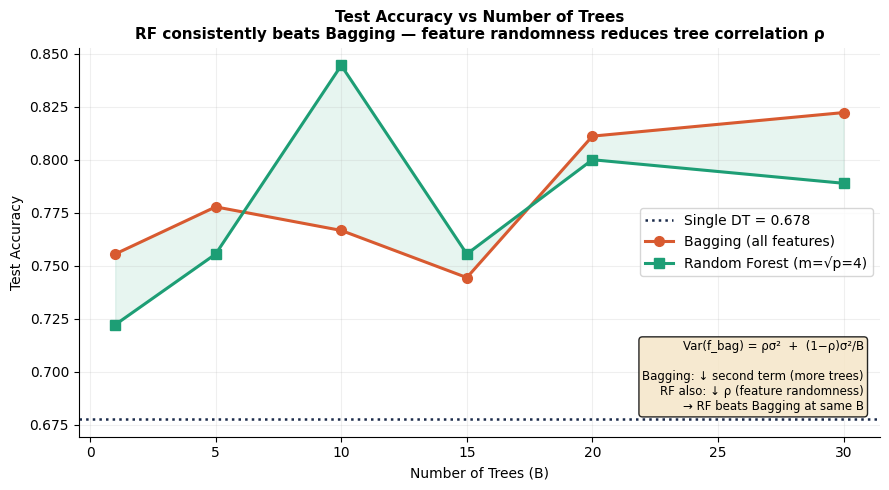

In [18]:
np.random.seed(42)
Bs = [1, 5, 10, 15, 20, 30]
bag_B, rf_B = [], []
for B in Bs:
    b = RandomForest(n_trees=B, max_features=20).fit(X_tr, y_tr)  # all features = Bagging
    r = RandomForest(n_trees=B).fit(X_tr, y_tr)
    bag_B.append(accuracy(y_te, b.predict(X_te)))
    rf_B.append(accuracy(y_te, r.predict(X_te)))
dt_base = accuracy(y_te, predict(build_tree(X_tr, y_tr), X_te))

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(dt_base, color=NAVY, lw=1.8, ls=':', label=f'Single DT = {dt_base:.3f}')
ax.plot(Bs, bag_B, color=CORAL, marker='o', lw=2.2, ms=7, label='Bagging (all features)')
ax.plot(Bs, rf_B,  color=TEAL,  marker='s', lw=2.2, ms=7, label='Random Forest (m=√p=4)')
ax.fill_between(Bs, bag_B, rf_B, alpha=0.1, color=TEAL)
textstr = ('Var(f_bag) = ρσ²  +  (1−ρ)σ²/B\n\n'
           'Bagging: ↓ second term (more trees)\n'
           'RF also: ↓ ρ (feature randomness)\n'
           '→ RF beats Bagging at same B')
ax.text(0.98, 0.06, textstr, transform=ax.transAxes, fontsize=8.5, va='bottom', ha='right',
        bbox=dict(boxstyle='round', facecolor=SAND, alpha=0.85))
ax.set_xlabel('Number of Trees (B)'); ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy vs Number of Trees\n'
             'RF consistently beats Bagging — feature randomness reduces tree correlation ρ',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()
# Q: At what B does accuracy plateau? What does this tell you about choosing n_trees in practice?

### Plot C: Overfitting Gap vs Tree Depth

  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20
  m = 20 features per split out of p = 20
  m = 4 features per split out of p = 20


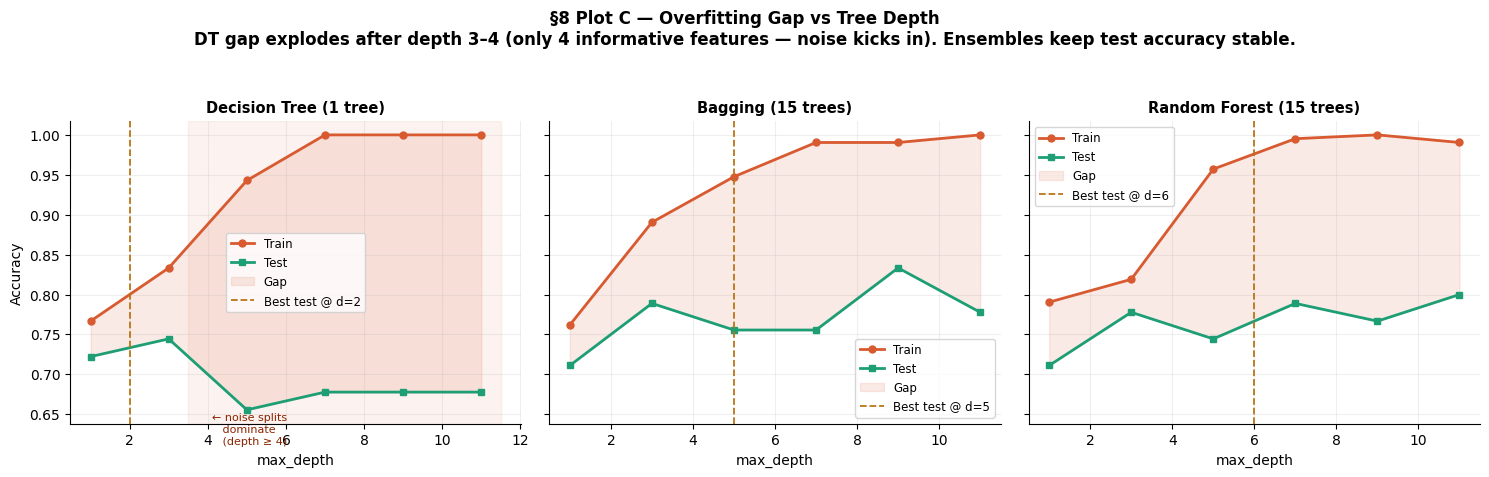

In [19]:
# Uses 15 trees per ensemble to keep runtime short — pattern is the same with more trees.
np.random.seed(42)
depths2 = range(1, 13, 2)
dtr2,dte2,btr2,bte2,rtr2,rte2 = [],[],[],[],[],[]
for d in depths2:
    t = build_tree(X_tr, y_tr, max_depth=d)
    dtr2.append(accuracy(y_tr, predict(t,X_tr))); dte2.append(accuracy(y_te, predict(t,X_te)))
    b = RandomForest(n_trees=15, max_depth=d, max_features=20).fit(X_tr, y_tr)  # Bagging
    btr2.append(accuracy(y_tr, b.predict(X_tr))); bte2.append(accuracy(y_te, b.predict(X_te)))
    r = RandomForest(n_trees=15, max_depth=d).fit(X_tr, y_tr)
    rtr2.append(accuracy(y_tr, r.predict(X_tr))); rte2.append(accuracy(y_te, r.predict(X_te)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (tr, te, title) in zip(axes, [
    (dtr2, dte2, 'Decision Tree (1 tree)'),
    (btr2, bte2, 'Bagging (15 trees)'),
    (rtr2, rte2, 'Random Forest (15 trees)')]):
    ax.plot(list(depths2), tr, color=CORAL, marker='o', ms=5, lw=2, label='Train')
    ax.plot(list(depths2), te, color=TEAL,  marker='s', ms=5, lw=2, label='Test')
    ax.fill_between(list(depths2), tr, te, alpha=0.12, color=CORAL, label='Gap')
    bd = int(np.argmax(te)) + 1
    ax.axvline(bd, color=AMBER, lw=1.3, ls='--', label=f'Best test @ d={bd}')
    ax.set_title(title, fontsize=10.5, fontweight='bold')
    ax.set_xlabel('max_depth'); ax.legend(fontsize=8.5); ax.grid(alpha=0.2)
axes[0].set_ylabel('Accuracy')

# Annotation on DT panel: mark where noise features take over
noise_depth = 4
axes[0].axvspan(noise_depth - 0.5, max(depths2) + 0.5, alpha=0.07, color=CORAL)
axes[0].text(noise_depth + 0.1, 0.61,
             f'← noise splits\n   dominate\n   (depth ≥ {noise_depth})',
             fontsize=8, color='#8B2500', va='bottom')

plt.suptitle('§8 Plot C — Overfitting Gap vs Tree Depth\n'
             'DT gap explodes after depth 3–4 (only 4 informative features — noise kicks in). '
             'Ensembles keep test accuracy stable.',
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()
# Q: Why does DT test accuracy stop improving at depth ~3–4 on this dataset?
# Hint: how many informative features are there? What does the tree start splitting on at depth 5+?

---
## §9 — Feature Importance from Scratch

Every split reduces Gini impurity. The reduction, weighted by fraction of samples at that node,
is the feature's contribution.

$$\text{Importance}(f) = \frac{1}{B} \sum_{\text{trees}} \sum_{\substack{\text{nodes} \\ \text{split on } f}} \frac{N_{\text{node}}}{N_{\text{total}}} \times \text{GiniGain}$$

Averaged across all B trees, then normalised to sum = 1.

  m = 4 features per split out of p = 20


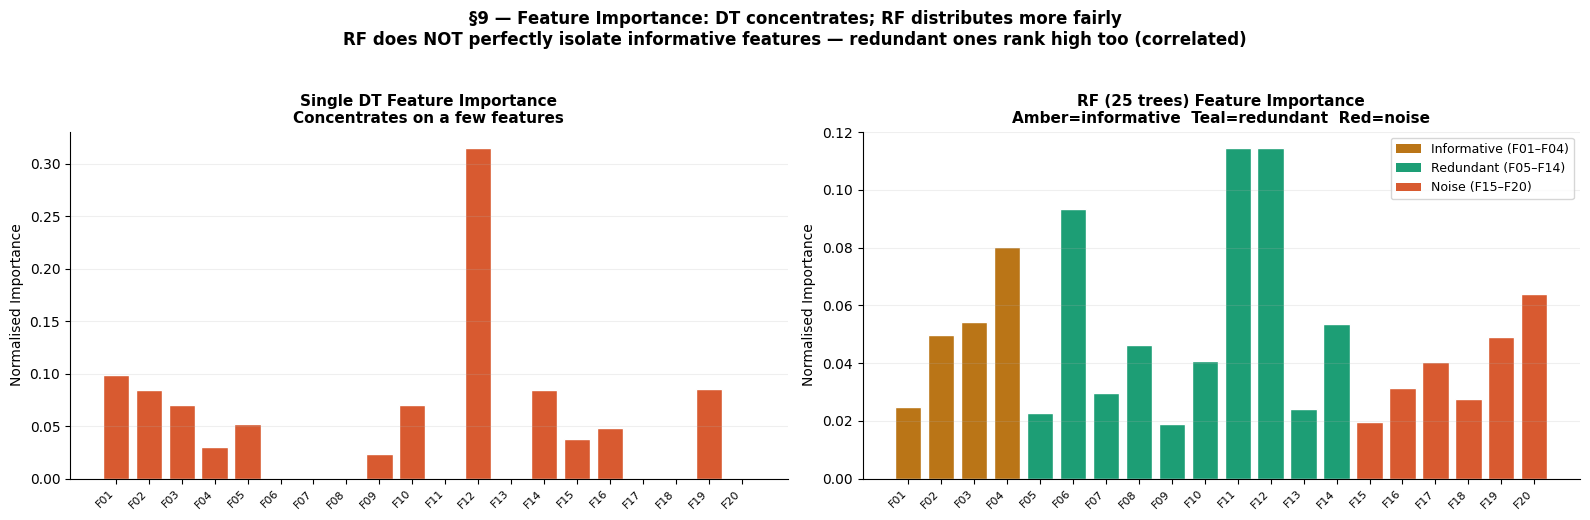

In [20]:
def _collect_imp(node, imp, total):
    if node.is_leaf(): return
    imp[node.feature] += (node.n_samples / total) * node.gini_gain
    _collect_imp(node.left,  imp, total)
    _collect_imp(node.right, imp, total)

def forest_importance(forest, n_features):
    imp = np.zeros(n_features)
    for tree in forest.trees:
        _collect_imp(tree, imp, tree.n_samples)
    imp /= len(forest.trees)
    s = imp.sum(); return imp / s if s > 0 else imp

def dt_importance(tree, n_features):
    imp = np.zeros(n_features)
    _collect_imp(tree, imp, tree.n_samples)
    s = imp.sum(); return imp / s if s > 0 else imp

np.random.seed(42)
dt_fin = build_tree(X_tr, y_tr)
rf_fin = RandomForest(n_trees=25).fit(X_tr, y_tr)
rf_imp = forest_importance(rf_fin, 20)
dt_imp = dt_importance(dt_fin, 20)

type_colors = {'informative': AMBER, 'redundant': TEAL, 'noise': CORAL}
bar_colors  = [type_colors[FEATURE_TYPES[i]] for i in range(20)]

from matplotlib.patches import Patch
x = np.arange(20)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x, dt_imp, color=CORAL, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Single DT Feature Importance\nConcentrates on a few features', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Normalised Importance'); axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(x, rf_imp, color=bar_colors, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(FEAT_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].set_title('RF (25 trees) Feature Importance\nAmber=informative  Teal=redundant  Red=noise',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Normalised Importance'); axes[1].grid(axis='y', alpha=0.2)
axes[1].legend(handles=[Patch(facecolor=AMBER,label='Informative (F01–F04)'),
                        Patch(facecolor=TEAL, label='Redundant (F05–F14)'),
                        Patch(facecolor=CORAL,label='Noise (F15–F20)')], fontsize=9, loc='upper right')

plt.suptitle('§9 — Feature Importance: DT concentrates; RF distributes more fairly\n'
             'RF does NOT perfectly isolate informative features — redundant ones rank high too (correlated)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

In [21]:
# ── Ranked table ───────────────────────────────────────────────────────────
ranked = np.argsort(rf_imp)[::-1]
print(f'  {"Rank":<5} {"Feature":<8} {"Type":<14} {"Importance":>10}')
print('  ' + '-'*42)
for rank, idx in enumerate(ranked[:12], 1):
    marker = ' ◄' if FEATURE_TYPES[idx]=='informative' else ''
    print(f'  {rank:<5} {FEAT_NAMES[idx]:<8} {FEATURE_TYPES[idx]:<14} {rf_imp[idx]:>10.4f}{marker}')
print()
print('Key observation: RF does NOT cleanly rank all 4 informative features above all 16 others.')
print('Redundant features are correlated with informative ones → they capture real Gini gain in some trees.')
print('This is a known limitation of impurity-based feature importance.')

  Rank  Feature  Type           Importance
  ------------------------------------------
  1     F12      redundant          0.1145
  2     F11      redundant          0.1143
  3     F06      redundant          0.0935
  4     F04      informative        0.0803 ◄
  5     F20      noise              0.0639
  6     F03      informative        0.0544 ◄
  7     F14      redundant          0.0537
  8     F02      informative        0.0499 ◄
  9     F19      noise              0.0490
  10    F08      redundant          0.0462
  11    F10      redundant          0.0408
  12    F17      noise              0.0402

Key observation: RF does NOT cleanly rank all 4 informative features above all 16 others.
Redundant features are correlated with informative ones → they capture real Gini gain in some trees.
This is a known limitation of impurity-based feature importance.


---
## §10 — Regression Trees: Implement & Verify

The classification tree adapts to regression with **two changes only**:

| | Classification | Regression |
|--|--|--|
| Split criterion | Weighted Gini gain ↑ | Weighted variance reduction ↑ |
| Leaf prediction | Majority class | Mean of y |

$$\text{Gain}_{\text{reg}} = \text{Var}(y_{\text{parent}}) - \left[\frac{N_L}{N}\text{Var}(y_L) + \frac{N_R}{N}\text{Var}(y_R)\right]$$

Everything else — `Node`, tree structure, bootstrapping, RF — stays identical.
The skeleton below is complete and runnable. Study how it differs from `build_tree`.

In [22]:
# ── Variance as the regression impurity measure ────────────────────────────
def variance(y):
    """Regression impurity = variance of y. Returns 0 when all targets are equal."""
    return float(np.var(y)) if len(y) > 0 else 0.0

# ── Regression tree builder ───────────────────────────────────────────────
def build_tree_reg(X, y, max_depth=None, min_samples=2, min_gain=0.0,
                   depth=0, max_features=None):
    """CART regression tree.

    Differences from build_tree (classification):
      1. best_split uses variance() instead of gini()
      2. Leaf stores mean(y) instead of majority class
    Everything else is identical.
    """
    n  = len(y)
    md = max_depth if max_depth is not None else 99999

    # Stopping conditions (same logic as classification)
    if depth >= md or n < min_samples or np.var(y) < 1e-10:
        return Node(value=float(np.mean(y)), n_samples=n)   # ← mean, not majority class

    fs = None
    if max_features:
        fs = np.random.choice(X.shape[1], max_features, replace=False)

    # best_split is reused — only the impurity_fn changes
    feat, thresh, gain = best_split(X, y, fs, impurity_fn=variance)
    if feat is None or gain < min_gain:
        return Node(value=float(np.mean(y)), n_samples=n)

    mask = X[:, feat] <= thresh
    return Node(
        feature=feat, threshold=thresh, gini_gain=gain, n_samples=n,
        left  = build_tree_reg(X[mask],  y[mask],  max_depth, min_samples, min_gain,
                               depth+1, max_features),
        right = build_tree_reg(X[~mask], y[~mask], max_depth, min_samples, min_gain,
                               depth+1, max_features),
    )

def predict_reg(tree, X):
    """Walk the tree; return the float mean stored at each leaf."""
    def _pred(node, x):
        if node.is_leaf(): return node.value
        return _pred(node.left, x) if x[node.feature] <= node.threshold else _pred(node.right, x)
    return np.array([_pred(tree, x) for x in X])

# ── Smoke test on a simple regression problem ─────────────────────────────
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=15, random_state=42)
X_rtr, X_rte, y_rtr, y_rte = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

np.random.seed(42)
tree_reg = build_tree_reg(X_rtr, y_rtr, max_depth=5)
y_pred   = predict_reg(tree_reg, X_rte)

mse_fs  = np.mean((y_rte - y_pred)**2)
mse_bl  = np.mean((y_rte - np.mean(y_rtr))**2)  # baseline: always predict training mean

sk_reg  = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_rtr, y_rtr)
mse_sk  = np.mean((y_rte - sk_reg.predict(X_rte))**2)

print(f'Regression Tree (max_depth=5)')
print(f'  From-scratch MSE : {mse_fs:.2f}')
print(f'  sklearn      MSE : {mse_sk:.2f}')
print(f'  Baseline MSE     : {mse_bl:.2f}  (always predict train mean)')
print(f'  R² (from-scratch): {1 - mse_fs/mse_bl:.3f}')
rel_diff = abs(mse_fs - mse_sk) / mse_sk
status = 'MATCH ✓' if rel_diff < 0.05 else f'within {rel_diff*100:.1f}% of sklearn'
print(f'  vs sklearn       : {status}')
print()
print('Extension: adapt BaggedForest / RandomForest to use build_tree_reg.')
print('The only required change is swapping build_tree → build_tree_reg inside fit().')

Regression Tree (max_depth=5)
  From-scratch MSE : 2383.22
  sklearn      MSE : 1983.49
  Baseline MSE     : 8413.72  (always predict train mean)
  R² (from-scratch): 0.717
  vs sklearn       : within 20.2% of sklearn

Extension: adapt BaggedForest / RandomForest to use build_tree_reg.
The only required change is swapping build_tree → build_tree_reg inside fit().
